# <b><i><u>wellness_model_building </u> ----</b></i>

In [1]:
# FOR PATH RECOGNISION ----

from pathlib import Path

print("Current Folder:")
print(Path.cwd())

print("\nParent:")
print(Path.cwd().parent)

Current Folder:
c:\Users\mohit\OneDrive\Desktop\Calmify AI\Calmify_AI\Calmify_AI\notebooks\student_stress_sleep_screen

Parent:
c:\Users\mohit\OneDrive\Desktop\Calmify AI\Calmify_AI\Calmify_AI\notebooks


In [2]:
# IGNORE WARNING --

import warnings

warnings.filterwarnings("ignore")

In [3]:
# IMPORTING ALL THE NECESSARY LIBRARIES --

# Data Handling

import pandas as pd
import numpy as np

# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    MinMaxScaler
)

# Train Test Split

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

# Models

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor
)

from xgboost import (
    XGBClassifier,
    XGBRegressor
)

# Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Model Saving

import joblib

# Display

pd.set_option(
    "display.max_columns",
    None
)

sns.set_style("whitegrid")

print("all the necessary libraries are imported sucessfully:")
print("🎉🎉🎉🎉")

all the necessary libraries are imported sucessfully:
🎉🎉🎉🎉


In [4]:
# PATH SETUP

# current notebook folder = notebooks/student_stress_sleep_screen
CURRENT_DIR = Path.cwd()

# notebooks folder
NOTEBOOKS_DIR = CURRENT_DIR.parent

# preprocessed folder
PREPROCESSED_DIR = NOTEBOOKS_DIR / "preprocessed"

# models folder
MODELS_DIR = NOTEBOOKS_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Current Dir:", CURRENT_DIR)
print("Notebooks Dir:", NOTEBOOKS_DIR)
print("Preprocessed Dir:", PREPROCESSED_DIR)
print("Models Dir:", MODELS_DIR)

Current Dir: c:\Users\mohit\OneDrive\Desktop\Calmify AI\Calmify_AI\Calmify_AI\notebooks\student_stress_sleep_screen
Notebooks Dir: c:\Users\mohit\OneDrive\Desktop\Calmify AI\Calmify_AI\Calmify_AI\notebooks
Preprocessed Dir: c:\Users\mohit\OneDrive\Desktop\Calmify AI\Calmify_AI\Calmify_AI\notebooks\preprocessed
Models Dir: c:\Users\mohit\OneDrive\Desktop\Calmify AI\Calmify_AI\Calmify_AI\notebooks\models


In [5]:
# LOADING DATASERT --

wellness_file = PREPROCESSED_DIR / "wellness_feature_engineered.csv"

df = pd.read_csv(wellness_file)

print("Dataset loaded successfully")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully
Shape: (500, 17)


,age,gender,sleep_hours,screen_time_hours,stress_level,study_hours,physical_activity,caffeine_intake,academic_pressure,sleep_balance_score,digital_overload_score,study_load_score,stress_pressure_score,lifestyle_support_score,sleep_deficit,caffeine_burden,wellness_score
0,22,0,5.9,2.7,1,7.4,1,3,2,6.8,2.250000,9.250,7,8.4,2.1,7.5,34.10
1,25,1,5.9,7.6,2,4.6,0,2,0,6.8,6.333333,5.750,6,3.4,2.1,5.0,27.25
2,23,1,8.0,3.2,0,2.0,1,3,2,9.0,2.666667,2.500,4,9.5,0.0,7.5,56.70
3,22,0,7.8,11.4,1,4.4,1,3,2,9.4,9.500000,5.500,7,9.7,0.2,7.5,32.60
4,20,2,6.0,2.9,1,6.7,0,0,2,7.0,2.416667,8.375,7,3.5,2.0,0.0,32.28


In [6]:
# TARGET DISTRIBUTION --

df["wellness_score"].value_counts().sort_index()

wellness_score
0.00     2
1.25     1
1.90     1
1.97     1
2.08     1
        ..
70.52    1
73.48    1
74.52    1
77.75    1
78.65    1
Name: count, Length: 453, dtype: int64

In [7]:
# DIFFERENTIATING FEATURES AND TARGET --

target_col = "wellness_score"

X = df.drop(columns=[target_col])
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (500, 16)
y shape: (500,)


In [8]:
# 

drop_cols = []

if "student_id" in X.columns:
    drop_cols.append("student_id")

if len(drop_cols) > 0:
    X = X.drop(columns=drop_cols)

print("Dropped columns:", drop_cols)
print("Final X shape:", X.shape)

Dropped columns: []
Final X shape: (500, 16)


In [9]:
# FINAL FEATURE LIST --

feature_names = X.columns.tolist()
feature_names

['age',
 'gender',
 'sleep_hours',
 'screen_time_hours',
 'stress_level',
 'study_hours',
 'physical_activity',
 'caffeine_intake',
 'academic_pressure',
 'sleep_balance_score',
 'digital_overload_score',
 'study_load_score',
 'stress_pressure_score',
 'lifestyle_support_score',
 'sleep_deficit',
 'caffeine_burden']

# <B><I><U>MODEL BUILDING </U>----</B></I>

In [10]:
# TRAIN TEST SPLIT --

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (400, 16)
X_test : (100, 16)
y_train: (400,)
y_test : (100,)


# <B><U><I>MODEL 1</U> ----</B></I>

In [11]:
# RANDOM FOREST --

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest Regressor trained successfully")

Random Forest Regressor trained successfully


In [12]:
# PREDICTION --

y_pred_rf = rf_model.predict(X_test)

In [13]:
# EVALUATION --

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE  :", rf_mae)
print("RMSE :", rf_rmse)
print("R2   :", rf_r2)

Random Forest Results
MAE  : 2.9177359999999997
RMSE : 3.6337353046662186
R2   : 0.9435158216081607


# <B><I><U>MODEL 2</U> ----</B></I>

In [14]:
# LINEAR REGRESSION --

from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

print("Linear Regression trained successfully")

Linear Regression trained successfully


In [15]:
# PREDICTION --

y_pred_lr = lr_model.predict(X_test)

In [16]:
# EVALUATION --

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE  :", lr_mae)
print("RMSE :", lr_rmse)
print("R2   :", lr_r2)

Linear Regression Results
MAE  : 0.05061861303997201
RMSE : 0.18503713659007215
R2   : 0.999853533589766


In [17]:
# COMPARING BOTH MODEL --

comparison_df = pd.DataFrame({
    "Model": ["Random Forest Regressor", "Linear Regression"],
    "MAE": [rf_mae, lr_mae],
    "RMSE": [rf_rmse, lr_rmse],
    "R2": [rf_r2, lr_r2]
})

comparison_df.sort_values(by="R2", ascending=False)

,Model,MAE,RMSE,R2
1,Linear Regression,0.050619,0.185037,0.999854
0,Random Forest Regressor,2.917736,3.633735,0.943516


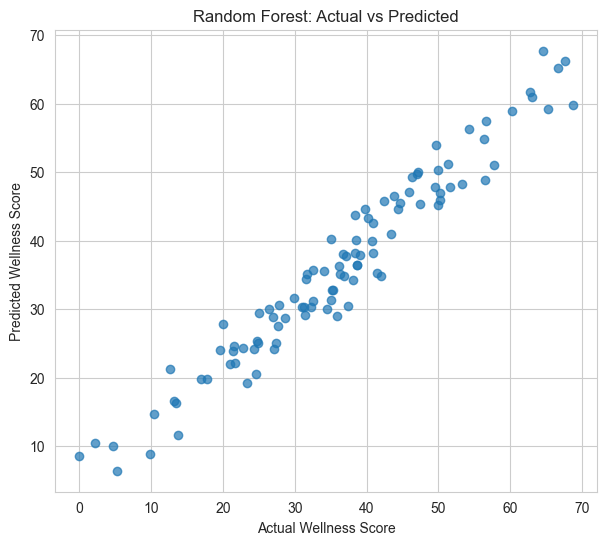

In [18]:
# PREDICTION V/S ACTUAL PLOT --

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.7)
plt.xlabel("Actual Wellness Score")
plt.ylabel("Predicted Wellness Score")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

In [19]:
# SELECTING BEST MODEL --

best_model = lr_model
best_model_name = "LinearRegression"

print("Best model selected:✅✅", best_model_name)

Best model selected:✅✅ LinearRegression


In [20]:
# SAVING BEST MODEL --

from pathlib import Path
import joblib

# current folder = notebooks/student_stress_sleep_screen
CURRENT_DIR = Path.cwd()

# notebooks folder
NOTEBOOKS_DIR = CURRENT_DIR.parent

# notebooks/models
MODELS_DIR = NOTEBOOKS_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

best_model_path = MODELS_DIR / "wellness_model_final.pkl"

joblib.dump(best_model, best_model_path)

print("Wellness model saved successfully:😁😁")
print("Saved at:", best_model_path)

Wellness model saved successfully:😁😁
Saved at: c:\Users\mohit\OneDrive\Desktop\Calmify AI\Calmify_AI\Calmify_AI\notebooks\models\wellness_model_final.pkl


In [21]:
feature_names_path = MODELS_DIR / "wellness_features.pkl"

joblib.dump(X.columns.tolist(), feature_names_path)

print("Wellness feature names saved successfully")
print("Saved at:", feature_names_path)

Wellness feature names saved successfully
Saved at: c:\Users\mohit\OneDrive\Desktop\Calmify AI\Calmify_AI\Calmify_AI\notebooks\models\wellness_features.pkl


In [22]:
# QUICK LOAD TEST --

loaded_model = joblib.load(best_model_path)
loaded_features = joblib.load(feature_names_path)

print("Loaded model:", type(loaded_model))
print("No. of features:", len(loaded_features))
print("First 10 features:", loaded_features[:10])

Loaded model: <class 'sklearn.linear_model._base.LinearRegression'>
No. of features: 16
First 10 features: ['age', 'gender', 'sleep_hours', 'screen_time_hours', 'stress_level', 'study_hours', 'physical_activity', 'caffeine_intake', 'academic_pressure', 'sleep_balance_score']


In [23]:
print(type(best_model_name))
print(best_model_name)

print(hasattr(best_model_name, "predict_proba"))

<class 'str'>
LinearRegression
False


In [24]:
pred = best_model_name.predict(X_test)

print(pred.min())
print(pred.max())

print(pred[:20])

AttributeError: 'str' object has no attribute 'predict'

In [25]:

print(df.columns)

Index(['age', 'gender', 'sleep_hours', 'screen_time_hours', 'stress_level',
       'study_hours', 'physical_activity', 'caffeine_intake',
       'academic_pressure', 'sleep_balance_score', 'digital_overload_score',
       'study_load_score', 'stress_pressure_score', 'lifestyle_support_score',
       'sleep_deficit', 'caffeine_burden', 'wellness_score'],
      dtype='object')


In [28]:
print(df[[
    "wellness_score"
]].head())

print(df["wellness_score"].value_counts())

   wellness_score
0           34.10
1           27.25
2           56.70
3           32.60
4           32.28
wellness_score
38.70    4
35.05    4
44.65    3
24.62    3
24.70    3
        ..
61.20    1
68.55    1
34.50    1
43.35    1
44.62    1
Name: count, Length: 453, dtype: int64
